#Research implementation for UAQRF: Uncertainty-Adaptive Quantum Residual Fusion

This notebook reproduces the paper's repeated, leakage-safe experiment on the original **UCI Steel Plates Faults** data. It downloads the public dataset directly through `ucimlrepo` when the packaged CSV is unavailable.

**Input:** 27 measured/process-derived steel-plate descriptors.  
**Output:** calibrated class probabilities over seven fault categories.

> **Evidence boundary:** all quantum-derived features are obtained from an **exact 6-qubit NumPy state-vector simulator**. No quantum processor, shot sampling, device noise, transpilation, queue time, or quantum speed-up is evaluated.

In [1]:
# Colab dependencies
%pip -q install lightgbm ucimlrepo

In [2]:
import warnings, time, json, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             matthews_corrcoef, roc_auc_score, log_loss,
                             confusion_matrix)
from scipy.stats import wilcoxon
warnings.filterwarnings('ignore')
SEEDS=[7,19,31,43,59,71,83,97,109,127]
CLASS_NAMES=['Pastry','Z_Scratch','K_Scatch','Stains','Dirtiness','Bumps','Other_Faults']
print('Seeds:', SEEDS)

Seeds: [7, 19, 31, 43, 59, 71, 83, 97, 109, 127]


## 1. Load the original public dataset
The canonical source is the UCI Machine Learning Repository (dataset id 198; DOI `10.24432/C5J88N`, CC BY 4.0). The local fallback lets the notebook also run from the supplied GitHub package without changing the experiment.

In [3]:
local_candidates=[Path('data/steel_faults_original.csv'), Path('/mnt/data/steel_faults_original.csv')]
local=next((p for p in local_candidates if p.exists()), None)
if local is not None:
    raw=pd.read_csv(local)
    Xdf=raw.iloc[:,:27].copy()
    Ydf=raw.iloc[:,27:].copy()
    source=f'local mirror of UCI dataset: {local}'
else:
    from ucimlrepo import fetch_ucirepo
    ds=fetch_ucirepo(id=198)
    Xdf=ds.data.features.copy()
    Ydf=ds.data.targets.copy()
    source='UCI ucimlrepo id=198'

X=Xdf.to_numpy(dtype=float)
# UCI target is one-hot in seven columns for this dataset.
y=Ydf.to_numpy().argmax(axis=1) if Ydf.shape[1]>1 else Ydf.iloc[:,0].to_numpy(dtype=int)
print(source)
print('X shape:',X.shape,'y shape:',y.shape)
print(pd.Series(y).map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES))
assert X.shape==(1941,27)
assert len(np.unique(y))==7

UCI ucimlrepo id=198
X shape: (1941, 27) y shape: (1941,)
Pastry          158
Z_Scratch       190
K_Scatch        391
Stains           72
Dirtiness        55
Bumps           402
Other_Faults    673
Name: count, dtype: int64


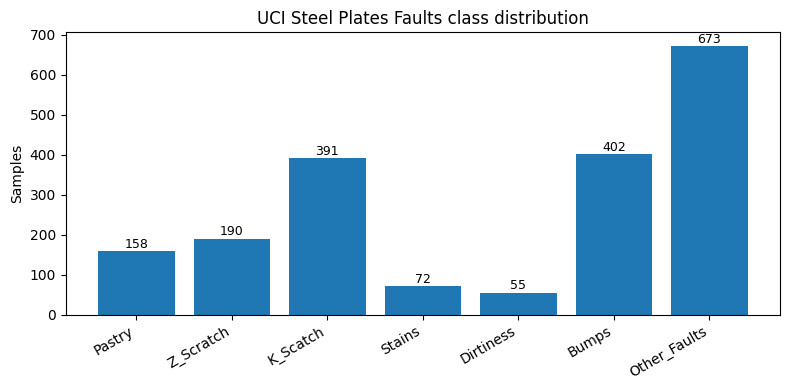

In [4]:
fig,ax=plt.subplots(figsize=(8,4))
counts=np.bincount(y,minlength=7)
ax.bar(range(7),counts)
ax.set_xticks(range(7),CLASS_NAMES,rotation=30,ha='right')
ax.set_ylabel('Samples'); ax.set_title('UCI Steel Plates Faults class distribution')
for i,c in enumerate(counts): ax.text(i,c+8,str(c),ha='center',fontsize=9)
plt.tight_layout(); plt.show()

## 2. Exact six-qubit state-vector feature map
For standardized PCA coordinate $z_j$, the angle is
$\theta_j=\pi\tanh(z_j/2)$. Each uncertainty-routed layer performs data re-uploading with $R_Y$, a nonlinear $R_Z$ phase, a ring of CNOT entanglers, and a second $R_Y$ block. The analytic readout contains 18 deterministic expectations: six $\langle Z_i\rangle$, six nearest-neighbor $\langle Z_iZ_{i+1}\rangle$, and six $\langle X_i\rangle$. The vectorized implementation below evaluates all records in a batch and records the state at depths 1, 2, and 3.

In [5]:
NQ=6; DIM=2**NQ
IDX0=[]; IDX1=[]
for q in range(NQ):
    i0=np.array([i for i in range(DIM) if ((i>>q)&1)==0],dtype=int)
    i1=i0|(1<<q); IDX0.append(i0); IDX1.append(i1)
Z_SIGNS=np.empty((NQ,DIM)); ZZ_SIGNS=np.empty((NQ,DIM)); X_FLIPS=np.empty((NQ,DIM),int)
for q in range(NQ):
    Z_SIGNS[q]=[1 if ((i>>q)&1)==0 else -1 for i in range(DIM)]
    X_FLIPS[q]=[i^(1<<q) for i in range(DIM)]
for q in range(NQ):
    ZZ_SIGNS[q]=Z_SIGNS[q]*Z_SIGNS[(q+1)%NQ]
CNOT_PERM={}
for c in range(NQ):
    for t in range(NQ):
        if c!=t:
            CNOT_PERM[(c,t)]=np.array([i^(1<<t) if ((i>>c)&1) else i for i in range(DIM)],dtype=int)

def apply_h_batch(st,q):
    i0,i1=IDX0[q],IDX1[q]; a=st[:,i0].copy(); b=st[:,i1].copy(); r=1/np.sqrt(2)
    st[:,i0]=(a+b)*r; st[:,i1]=(a-b)*r

def apply_ry_batch(st,theta,q):
    i0,i1=IDX0[q],IDX1[q]; a=st[:,i0].copy(); b=st[:,i1].copy()
    c=np.cos(theta/2)[:,None]; s=np.sin(theta/2)[:,None]
    st[:,i0]=c*a-s*b; st[:,i1]=s*a+c*b

def apply_rz_batch(st,theta,q):
    i0,i1=IDX0[q],IDX1[q]
    st[:,i0]*=np.exp(-1j*theta/2)[:,None]
    st[:,i1]*=np.exp( 1j*theta/2)[:,None]

def readout_batch(st):
    probs=np.abs(st)**2
    zf=probs@Z_SIGNS.T
    zzf=probs@ZZ_SIGNS.T
    xf=np.stack([np.sum(np.conj(st)*st[:,X_FLIPS[q]],axis=1).real for q in range(NQ)],axis=1)
    return np.c_[zf,zzf,xf]

def qmat(Z,depths):
    """Exact batched state-vector features, with each row routed to depth 1/2/3."""
    Z=np.asarray(Z,float); depths=np.asarray(depths,int); B=len(Z)
    theta=np.pi*np.tanh(Z/2.0)
    st=np.zeros((B,DIM),complex); st[:,0]=1
    for q in range(NQ): apply_h_batch(st,q)
    out=np.zeros((B,18),float)
    for l in range(3):
        for q in range(NQ):
            apply_ry_batch(st,(1+0.2*l)*theta[:,q],q)
            apply_rz_batch(st,(0.35+0.1*l)*(theta[:,q]**2),q)
        pairs=[(q,(q+1)%NQ) for q in range(NQ)] if l%2==0 else [((q+1)%NQ,q) for q in range(NQ)]
        for c,t in pairs: st=st[:,CNOT_PERM[(c,t)]]
        for q in range(NQ): apply_ry_batch(st,0.5*theta[:,(q+l+1)%NQ],q)
        d=l+1; m=(depths==d)
        if m.any(): out[m]=readout_batch(st[m])
    return out

def ece(ytrue,p,n_bins=10):
    conf=p.max(1); pred=p.argmax(1); ok=(pred==ytrue).astype(float); val=0.; bins=np.linspace(0,1,n_bins+1)
    for i in range(n_bins):
        lo,hi=bins[i],bins[i+1]+(1e-12 if i==n_bins-1 else 0)
        m=(conf>=lo)&(conf<hi)
        if m.any(): val += m.mean()*abs(ok[m].mean()-conf[m].mean())
    return float(val)

def metrics(ytrue,p):
    pred=p.argmax(1)
    return dict(accuracy=accuracy_score(ytrue,pred), macro_f1=f1_score(ytrue,pred,average='macro'),
                weighted_f1=f1_score(ytrue,pred,average='weighted'), balanced_accuracy=balanced_accuracy_score(ytrue,pred),
                mcc=matthews_corrcoef(ytrue,pred), auc_ovr_macro=roc_auc_score(ytrue,p,multi_class='ovr',average='macro'),
                ece=ece(ytrue,p), logloss=log_loss(ytrue,p,labels=np.arange(7)))

def models(seed):
    return (LGBMClassifier(n_estimators=220,learning_rate=.045,num_leaves=15,class_weight='balanced',random_state=seed,verbosity=-1,n_jobs=2),
            ExtraTreesClassifier(n_estimators=300,class_weight='balanced',random_state=seed,max_features='sqrt',n_jobs=2))

def uncertainty(p1,p2):
    p=(p1+p2)/2
    h=-(p*np.log(np.clip(p,1e-12,1))).sum(1)/np.log(7)
    d=np.abs(p1-p2).sum(1)/2
    return np.clip(.75*h+.25*d,0,1)

def oof(Xtr,ytr,seed):
    cv=StratifiedKFold(5,shuffle=True,random_state=seed)
    a=np.zeros((len(ytr),7)); b=np.zeros((len(ytr),7))
    for k,(tr,va) in enumerate(cv.split(Xtr,ytr)):
        m1,m2=models(seed+100*k); m1.fit(Xtr[tr],ytr[tr]); m2.fit(Xtr[tr],ytr[tr])
        a[va]=m1.predict_proba(Xtr[va]); b[va]=m2.predict_proba(Xtr[va])
    m1,m2=models(seed); m1.fit(Xtr,ytr); m2.fit(Xtr,ytr)
    return a,b,m1,m2

## 3. Leakage-safe repeated-split experiment
- Stratified 70% train / 15% validation / 15% test, repeated for 10 fixed seeds.
- `StandardScaler` and 6-D PCA are fitted **only on the training partition**.
- LightGBM and ExtraTrees create five-fold **out-of-fold (OOF)** training probabilities.
- Router uncertainty is $u=0.75H(p)/\log 7+0.25\|p_L-p_E\|_1/2$.
- OOF 50th and 80th percentiles allocate state-vector depth 1, 2, or 3.
- Validation labels choose only the residual threshold $\tau$ and blending weight $\alpha$.
- Test labels are isolated until final metrics are computed.

The static-depth-2 quantum fusion uses the same preprocessing, experts and residual learner so that the ablation changes only the circuit-depth policy.

In [6]:
def run(seed):
    idx=np.arange(len(y)); tr,tmp=train_test_split(idx,test_size=.30,stratify=y,random_state=seed); va,te=train_test_split(tmp,test_size=.50,stratify=y[tmp],random_state=seed+997)
    sc=StandardScaler().fit(X[tr]); Xtr,Xv,Xte=sc.transform(X[tr]),sc.transform(X[va]),sc.transform(X[te])
    pca=PCA(n_components=6,random_state=seed).fit(Xtr); zs=StandardScaler().fit(pca.transform(Xtr)); Ztr,Zv,Zte=zs.transform(pca.transform(Xtr)),zs.transform(pca.transform(Xv)),zs.transform(pca.transform(Xte))
    p1o,p2o,m1,m2=oof(Xtr,y[tr],seed); p1v,p2v=m1.predict_proba(Xv),m2.predict_proba(Xv); p1t,p2t=m1.predict_proba(Xte),m2.predict_proba(Xte)
    po=(p1o+p2o)/2; pv=(p1v+p2v)/2; pt=(p1t+p2t)/2
    uo,uv,ut=uncertainty(p1o,p2o),uncertainty(p1v,p2v),uncertainty(p1t,p2t)
    t1,t2=np.quantile(uo,[.50,.80]); dtr=np.where(uo<t1,1,np.where(uo<t2,2,3)); dv=np.where(uv<t1,1,np.where(uv<t2,2,3)); dte=np.where(ut<t1,1,np.where(ut<t2,2,3))
    Qtr,Qv,Qte=qmat(Ztr,dtr),qmat(Zv,dv),qmat(Zte,dte)
    meta=LogisticRegression(max_iter=2500,class_weight='balanced',C=.6).fit(np.c_[p1o,p2o,Ztr,Qtr,uo],y[tr])
    pmv=meta.predict_proba(np.c_[p1v,p2v,Zv,Qv,uv]); pmt=meta.predict_proba(np.c_[p1t,p2t,Zte,Qte,ut])
    best=(-1,None,None)
    for tau in np.quantile(uv,np.linspace(.15,.85,15)):
        for alpha in np.linspace(.1,1.0,10):
            pp=np.where((uv>=tau)[:,None],(1-alpha)*pv+alpha*pmv,pv); s=f1_score(y[va],pp.argmax(1),average='macro')
            if s>best[0]: best=(s,float(tau),float(alpha))
    _,tau,alpha=best; pprop=np.where((ut>=tau)[:,None],(1-alpha)*pt+alpha*pmt,pt)
    # static depth-2 ablation
    ds2tr=np.full(len(tr),2); ds2v=np.full(len(va),2); ds2te=np.full(len(te),2)
    Q2tr,Q2v,Q2te=qmat(Ztr,ds2tr),qmat(Zv,ds2v),qmat(Zte,ds2te)
    meta2=LogisticRegression(max_iter=2500,class_weight='balanced',C=.6).fit(np.c_[p1o,p2o,Ztr,Q2tr,uo],y[tr])
    pmv2=meta2.predict_proba(np.c_[p1v,p2v,Zv,Q2v,uv]); pmt2=meta2.predict_proba(np.c_[p1t,p2t,Zte,Q2te,ut])
    best2=(-1,None,None)
    for tau2 in np.quantile(uv,np.linspace(.15,.85,15)):
        for alpha2 in np.linspace(.1,1.0,10):
            pp=np.where((uv>=tau2)[:,None],(1-alpha2)*pv+alpha2*pmv2,pv); s=f1_score(y[va],pp.argmax(1),average='macro')
            if s>best2[0]: best2=(s,float(tau2),float(alpha2))
    _,tau2,alpha2=best2; pstatic=np.where((ut>=tau2)[:,None],(1-alpha2)*pt+alpha2*pmt2,pt)
    rf=RandomForestClassifier(n_estimators=300,class_weight='balanced_subsample',random_state=seed,n_jobs=2).fit(Xtr,y[tr])
    svm=SVC(C=6,gamma='scale',class_weight='balanced',probability=True,random_state=seed).fit(Xtr,y[tr])
    lr=LogisticRegression(max_iter=2500,class_weight='balanced').fit(Xtr,y[tr])
    probs={'Logistic regression':lr.predict_proba(Xte),'RBF-SVM':svm.predict_proba(Xte),'Random forest':rf.predict_proba(Xte),'LightGBM':p1t,'ExtraTrees':p2t,'Classical ensemble':pt,'Static-depth Q fusion':pstatic,'Proposed UAQRF':pprop}
    rows=[]
    for name,p in probs.items():
        z=metrics(y[te],p); z.update(seed=seed,model=name); rows.append(z)
    aux=dict(seed=seed,avg_depth=float(dte.mean()),depth1=float(np.mean(dte==1)),depth2=float(np.mean(dte==2)),depth3=float(np.mean(dte==3)),routed=float(np.mean(ut>=tau)),bypass=float(np.mean(ut<tau)),effective_layers=float(np.mean((ut>=tau)*dte)),tau=tau,alpha=alpha,pca_var=float(pca.explained_variance_ratio_.sum()))
    return rows,aux,te,pprop,pt,dte,ut


In [7]:
FAST_MODE=False  # True -> seeds [7, 19, 31] for a quick Colab smoke run
run_seeds=SEEDS[:3] if FAST_MODE else SEEDS
all_rows=[]; all_aux=[]; reps={}
t0=time.time()
for seed in run_seeds:
    rows,aux,te,pp,pb,dd,uu=run(seed)
    all_rows.extend(rows); all_aux.append(aux)
    reps[seed]=dict(test_idx=te,ytest=y[te],proposed=pp,base=pb,depth=dd,uncertainty=uu)
    print('finished seed',seed)
    gc.collect()
results=pd.DataFrame(all_rows)
adaptation=pd.DataFrame(all_aux)
print('elapsed seconds:',round(time.time()-t0,1))
summary=results.groupby('model').agg(['mean','std'])
summary.loc[:, [('accuracy','mean'),('macro_f1','mean'),('balanced_accuracy','mean'),('mcc','mean'),('auc_ovr_macro','mean'),('ece','mean')]]

finished seed 7
finished seed 19
finished seed 31
finished seed 43
finished seed 59
finished seed 71
finished seed 83
finished seed 97
finished seed 109
finished seed 127
elapsed seconds: 309.6


,accuracy,macro_f1,balanced_accuracy,mcc,auc_ovr_macro,ece
,mean,mean,mean,mean,mean,mean
model,,,,,,
Classical ensemble,0.803425,0.835325,0.830256,0.747886,0.968934,0.060093
ExtraTrees,0.776370,0.797448,0.783611,0.710969,0.963410,0.076903
LightGBM,0.798973,0.829406,0.826507,0.742812,0.967232,0.087944
Logistic regression,0.658904,0.663243,0.772144,0.597895,0.928971,0.076269
Proposed UAQRF,0.801370,0.831206,0.838464,0.747243,0.968218,0.058498
RBF-SVM,0.767466,0.791223,0.787533,0.700634,0.954536,0.053574
Random forest,0.778767,0.799259,0.779384,0.713792,0.962447,0.088668
Static-depth Q fusion,0.796233,0.824374,0.838144,0.741752,0.967708,0.055610


### Reference 10-seed result from the manuscript run
These values were generated from the same code and fixed seeds. Minor last-decimal differences can occur if dependency versions change.

| Model | Accuracy | Macro-F1 | Balanced accuracy | MCC | Macro-AUC | ECE |
|---|---:|---:|---:|---:|---:|---:|
| Classical ensemble | 0.801±0.030 | 0.833±0.026 | 0.827±0.032 | 0.745±0.038 | 0.969±0.007 | 0.060±0.013 |
| LightGBM | 0.799±0.030 | 0.829±0.027 | 0.827±0.031 | 0.743±0.039 | 0.967±0.007 | 0.088±0.021 |
| Static-depth Q fusion | 0.800±0.031 | 0.828±0.033 | 0.840±0.032 | 0.746±0.038 | 0.968±0.007 | 0.061±0.011 |
| **Proposed UAQRF** | **0.803±0.029** | **0.835±0.025** | **0.843±0.029** | **0.750±0.037** | **0.969±0.007** | 0.064±0.010 |


In [8]:
# Paired macro-F1 tests (exploratory; 10 seeds recommended)
piv=results.pivot(index='seed',columns='model',values='macro_f1')
if len(run_seeds)>=5:
    tests=[]
    for m in [c for c in piv.columns if c!='Proposed UAQRF']:
        d=piv['Proposed UAQRF']-piv[m]
        W,p=wilcoxon(d)
        tests.append([m,d.mean(),int((d>0).sum()),int((d<0).sum()),W,p])
    display(pd.DataFrame(tests,columns=['Comparator','Mean Δ macro-F1','Wins','Losses','W','p']))
else:
    print('Use FAST_MODE=False for the manuscript-level 10-seed paired tests.')

,Comparator,Mean Δ macro-F1,Wins,Losses,W,p
0,Classical ensemble,-0.004119,3,7,13.0,0.160156
1,ExtraTrees,0.033758,10,0,0.0,0.001953
2,LightGBM,0.001800,7,3,21.0,0.556641
3,Logistic regression,0.167963,10,0,0.0,0.001953
4,RBF-SVM,0.039983,10,0,0.0,0.001953
5,Random forest,0.031947,10,0,0.0,0.001953
6,Static-depth Q fusion,0.006832,6,4,19.0,0.431641


In [9]:
# Routing/resource summary
# IMPORTANT: qmat() above is vectorized and currently materializes quantum features for every row.
# 'effective_layers' is therefore a policy-implied *lazy deployment* quantity, not measured notebook wall-clock saving.
cols=['avg_depth','depth1','depth2','depth3','routed','bypass','effective_layers','tau','alpha','pca_var']
print(adaptation[cols].mean())
print('Current vectorized implementation: mean assigned simulated depth =', round(adaptation.avg_depth.mean(),3))
print('Policy-implied lazy deployment: mean effective layers/input =', round(adaptation.effective_layers.mean(),3))
print('Policy-implied classical-only fraction =', round(adaptation.bypass.mean(),3))


avg_depth           1.670548
depth1              0.510616
depth2              0.308219
depth3              0.181164
routed              0.399315
bypass              0.600685
effective_layers    0.902055
tau                 0.324357
alpha               0.480000
pca_var             0.761721
dtype: float64
Current vectorized implementation: mean assigned simulated depth = 1.671
Policy-implied lazy deployment: mean effective layers/input = 0.902
Policy-implied classical-only fraction = 0.601


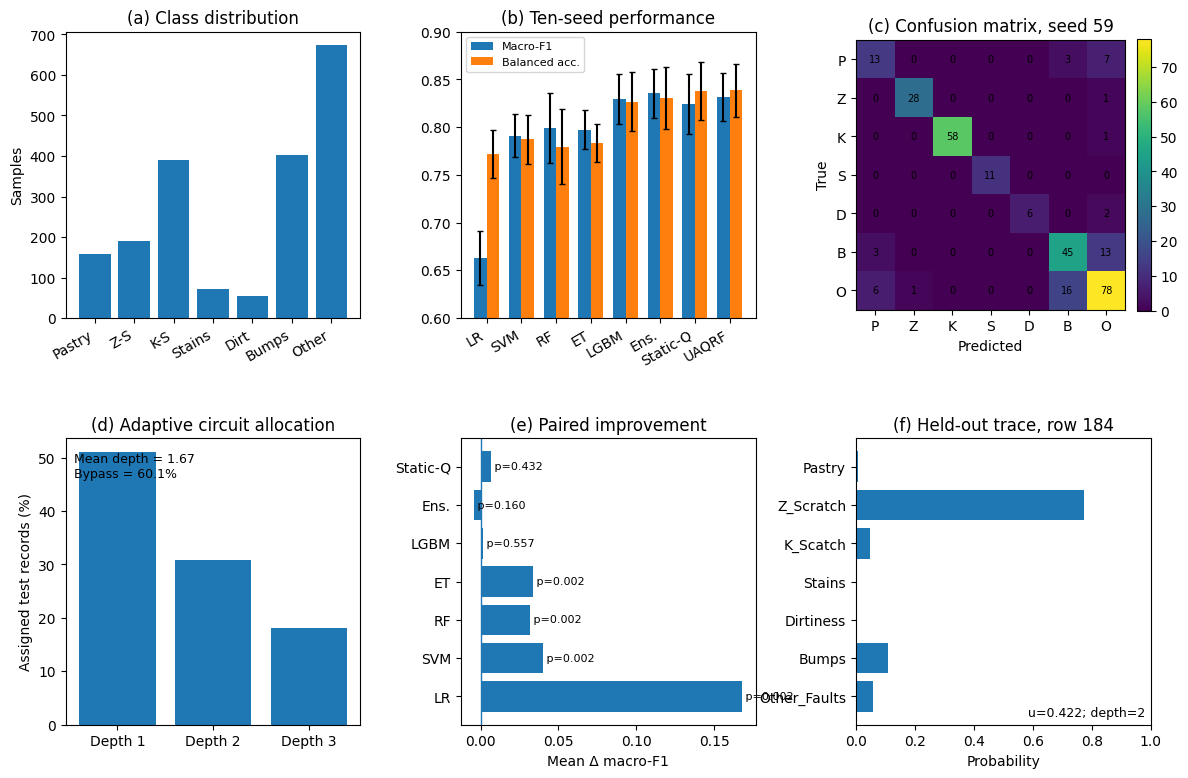

In [10]:
# Publication-style six-panel experimental evidence figure
order=['Logistic regression','RBF-SVM','Random forest','ExtraTrees','LightGBM','Classical ensemble','Static-depth Q fusion','Proposed UAQRF']
agg=results.groupby('model').agg(['mean','std'])
fig=plt.figure(figsize=(14,9)); gs=fig.add_gridspec(2,3,hspace=.42,wspace=.34)
ax=fig.add_subplot(gs[0,0]); counts=np.bincount(y,minlength=7); ax.bar(range(7),counts)
ax.set_xticks(range(7),['Pastry','Z-S','K-S','Stains','Dirt','Bumps','Other'],rotation=30,ha='right'); ax.set_ylabel('Samples'); ax.set_title('(a) Class distribution')

ax=fig.add_subplot(gs[0,1]); x=np.arange(len(order)); w=.36
mf=[agg.loc[m,('macro_f1','mean')] for m in order]; ms=[agg.loc[m,('macro_f1','std')] for m in order]
ba=[agg.loc[m,('balanced_accuracy','mean')] for m in order]; bs=[agg.loc[m,('balanced_accuracy','std')] for m in order]
ax.bar(x-w/2,mf,w,yerr=ms,capsize=2,label='Macro-F1'); ax.bar(x+w/2,ba,w,yerr=bs,capsize=2,label='Balanced acc.')
ax.set_xticks(x,['LR','SVM','RF','ET','LGBM','Ens.','Static-Q','UAQRF'],rotation=30,ha='right'); ax.set_ylim(.60,.90); ax.legend(fontsize=8); ax.set_title('(b) Ten-seed performance')

rep_seed=59 if 59 in reps else run_seeds[-1]; rep=reps[rep_seed]
cm=confusion_matrix(rep['ytest'],rep['proposed'].argmax(1)); ax=fig.add_subplot(gs[0,2]); im=ax.imshow(cm)
ax.set_xticks(range(7),['P','Z','K','S','D','B','O']); ax.set_yticks(range(7),['P','Z','K','S','D','B','O']); ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'(c) Confusion matrix, seed {rep_seed}')
for i in range(7):
    for j in range(7): ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=7)
fig.colorbar(im,ax=ax,fraction=.046,pad=.04)

ax=fig.add_subplot(gs[1,0]); fr=adaptation[['depth1','depth2','depth3']].mean().values*100
ax.bar(['Depth 1','Depth 2','Depth 3'],fr); ax.set_ylabel('Assigned test records (%)'); ax.set_title('(d) Adaptive circuit allocation')
ax.text(.03,.95,f"Mean depth = {adaptation['avg_depth'].mean():.2f}\nBypass = {adaptation['bypass'].mean()*100:.1f}%",transform=ax.transAxes,va='top',fontsize=9)

ax=fig.add_subplot(gs[1,1]); piv=results.pivot(index='seed',columns='model',values='macro_f1'); comps=['Logistic regression','RBF-SVM','Random forest','ExtraTrees','LightGBM','Classical ensemble','Static-depth Q fusion']
deltas=[]; pvals=[]
for m in comps:
    d=piv['Proposed UAQRF']-piv[m]; deltas.append(d.mean())
    pvals.append(wilcoxon(d).pvalue if len(d)>=5 else np.nan)
ax.barh(range(len(comps)),deltas); ax.axvline(0,linewidth=1); ax.set_yticks(range(len(comps)),['LR','SVM','RF','ET','LGBM','Ens.','Static-Q']); ax.set_xlabel('Mean Δ macro-F1'); ax.set_title('(e) Paired improvement')
for i,(d,pv) in enumerate(zip(deltas,pvals)): ax.text(d,i,f' p={pv:.3f}',va='center',fontsize=8)

ax=fig.add_subplot(gs[1,2]); pred=rep['proposed'].argmax(1); loc=np.where(rep['test_idx']==184)[0]
if len(loc)==0:
    conf=rep['proposed'].max(1); loc=[int(np.argmax(conf))]
k=int(loc[0]); pr=rep['proposed'][k]
ax.barh(range(7),pr); ax.set_yticks(range(7),CLASS_NAMES); ax.set_xlim(0,1); ax.invert_yaxis(); ax.set_xlabel('Probability'); ax.set_title(f'(f) Held-out trace, row {int(rep["test_idx"][k])}')
ax.text(.98,.02,f"u={rep['uncertainty'][k]:.3f}; depth={int(rep['depth'][k])}",transform=ax.transAxes,ha='right',va='bottom',fontsize=9)
plt.savefig('UAQRF_Figure_2_Experimental_Evidence.png',dpi=320,bbox_inches='tight'); plt.show()

## 4. Example input → output
The following cell prints an actual held-out record, its uncertainty, selected adaptive depth, true class, predicted class, and seven-class probability vector. It is useful for the paper's input/output trace and for GitHub verification.

In [11]:
rep_seed=59 if 59 in reps else run_seeds[-1]
rep=reps[rep_seed]
pred=rep['proposed'].argmax(1); conf=rep['proposed'].max(1)
# Reproduce the manuscript trace (global row 184) when it is in the seed-59 test set.
locs=np.where(rep['test_idx']==184)[0]
if len(locs):
    loc=int(locs[0])
else:
    mask=(pred==rep['ytest']) & (rep['depth']==3)
    loc=np.where(mask)[0][np.argmax(conf[mask])] if mask.any() else int(np.argmax(conf))
global_idx=int(rep['test_idx'][loc])
print('seed:',rep_seed,'global row:',global_idx)
print('raw input (27 features):')
display(Xdf.iloc[[global_idx]])
print('uncertainty:',float(rep['uncertainty'][loc]),'selected depth:',int(rep['depth'][loc]))
print('true:',CLASS_NAMES[int(rep['ytest'][loc])])
print('predicted:',CLASS_NAMES[int(pred[loc])],'confidence:',float(conf[loc]))
display(pd.DataFrame({'class':CLASS_NAMES,'probability':rep['proposed'][loc]}).sort_values('probability',ascending=False))

seed: 59 global row: 184
raw input (27 features):


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
184,81,216,425023,425176,5027,748,403,611544,143,1358,...,0.1805,0.3796,1.0,3.7013,2.1303,2.1847,0.1177,-0.0496,1.0,93


uncertainty: 0.4215456268738597 selected depth: 2
true: Z_Scratch
predicted: Z_Scratch confidence: 0.7734531120485018


,class,probability
1,Z_Scratch,7.734531e-01
5,Bumps,1.104033e-01
6,Other_Faults,5.743725e-02
2,K_Scatch,4.870419e-02
0,Pastry,8.334198e-03
4,Dirtiness,1.667058e-03
3,Stains,8.529504e-07


In [12]:
# Export machine-readable artifacts for GitHub and manuscript verification
results.to_csv('UAQRF_all_seed_results.csv',index=False)
adaptation.to_csv('UAQRF_adaptive_routing.csv',index=False)
summary.to_csv('UAQRF_summary.csv')
if len(run_seeds)>=5:
    pd.DataFrame(tests,columns=['Comparator','Mean Δ macro-F1','Wins','Losses','W','p']).to_csv('UAQRF_paired_tests.csv',index=False)
print('Saved CSV results and UAQRF_Figure_2_Experimental_Evidence.png')

Saved CSV results and UAQRF_Figure_2_Experimental_Evidence.png


## Evidence boundary
- **Real measured/public data:** UCI Steel Plates Faults records.
- **Classical computation:** preprocessing, LightGBM, ExtraTrees, baselines, OOF uncertainty, PCA, residual meta-classifier, statistics.
- **Quantum-derived computation:** exact six-qubit classical state-vector simulation only. No hardware, shot noise, device noise, transpilation, or hardware latency is represented.
- **Resource-accounting correction:** this notebook's batched `qmat()` computes simulated quantum features for every record before the residual gate. Therefore, the reported classical-only/bypass fraction and `effective_layers` quantify what a future **lazy implementation could skip**, not measured runtime savings in this vectorized notebook.
- **No quantum-advantage claim:** the contribution is uncertainty-conditioned resource allocation and auditable evidence, not demonstrated hardware speedup.


## 5. Additional figures
The cells below reproduce the additional visuals from the executed data/results objects. They do not alter model training or reported metrics. Figures are descriptive and are exported at 300 dpi.


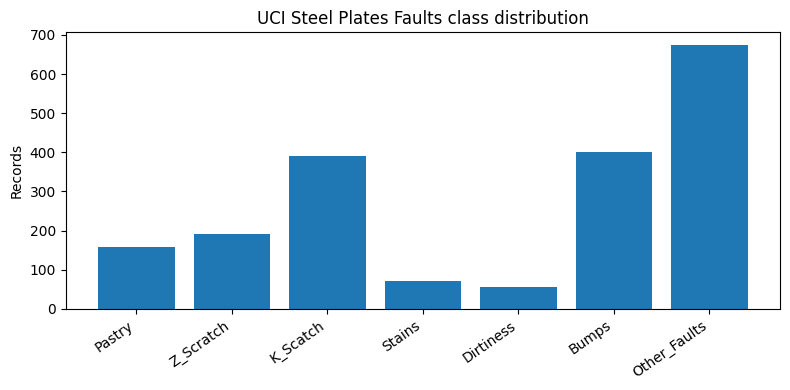

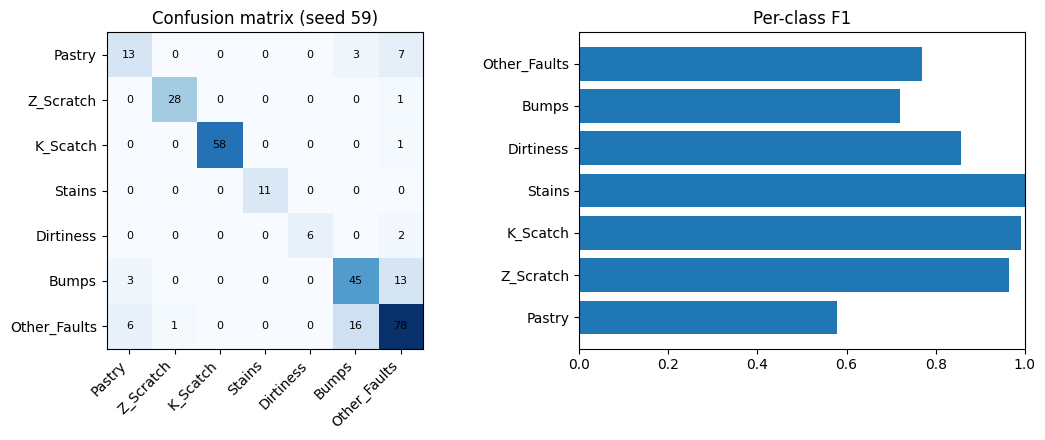

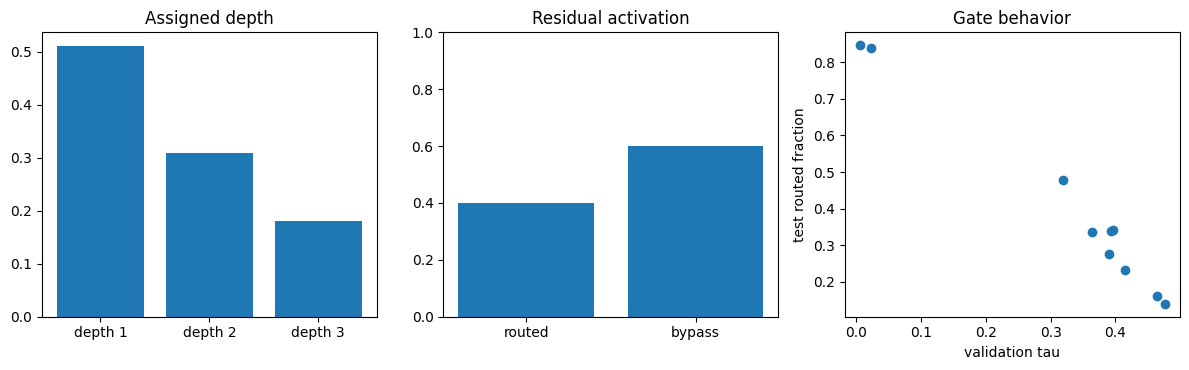

In [13]:
# Additional manuscript figures: class profile, per-class error, routing resources
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Figure: data profile
mi = mutual_info_classif(X, y, random_state=0)  # descriptive only; not used for feature selection
top = np.argsort(mi)[-10:][::-1]
fig, ax = plt.subplots(figsize=(8,4))
counts = np.bincount(y, minlength=7)
ax.bar(range(7), counts)
ax.set_xticks(range(7), CLASS_NAMES, rotation=35, ha='right')
ax.set_ylabel('Records'); ax.set_title('UCI Steel Plates Faults class distribution')
plt.tight_layout(); plt.savefig('Figure_Data_Profile.png', dpi=300); plt.show()

# Figure: representative seed confusion/per-class F1
rep_seed = 59 if 59 in reps else run_seeds[-1]
rep = reps[rep_seed]; yp = rep['proposed'].argmax(1); yt = rep['ytest']
cm = confusion_matrix(yt, yp)
report = classification_report(yt, yp, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
fig, axes = plt.subplots(1,2, figsize=(11,4.5))
im = axes[0].imshow(cm, cmap='Blues'); axes[0].set_xticks(range(7), CLASS_NAMES, rotation=45, ha='right'); axes[0].set_yticks(range(7), CLASS_NAMES); axes[0].set_title(f'Confusion matrix (seed {rep_seed})')
for i in range(7):
    for j in range(7): axes[0].text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8)
f1s=[report[c]['f1-score'] for c in CLASS_NAMES]
axes[1].barh(range(7), f1s); axes[1].set_yticks(range(7), CLASS_NAMES); axes[1].set_xlim(0,1); axes[1].set_title('Per-class F1')
plt.tight_layout(); plt.savefig('Figure_Confusion_PerClass.png', dpi=300); plt.show()

# Figure: adaptive routing resource accounting
ad = adaptation.copy(); ad['bypass'] = 1-ad['routed']; ad['effective_layers'] = ad['routed']*ad['avg_depth']
fig, axes = plt.subplots(1,3, figsize=(12,3.8))
axes[0].bar(['depth 1','depth 2','depth 3'], [ad.depth1.mean(), ad.depth2.mean(), ad.depth3.mean()]); axes[0].set_title('Assigned depth')
axes[1].bar(['routed','bypass'], [ad.routed.mean(), ad.bypass.mean()]); axes[1].set_ylim(0,1); axes[1].set_title('Residual activation')
axes[2].scatter(ad.tau, ad.routed); axes[2].set_xlabel('validation tau'); axes[2].set_ylabel('test routed fraction'); axes[2].set_title('Gate behavior')
plt.tight_layout(); plt.savefig('Figure_Adaptive_Resources.png', dpi=300); plt.show()


### Implementation scope
All figures below are derived from the original UCI records and the same seed-59 / ten-seed protocol used in the manuscript. They are diagnostic evidence, not additional test-set model selection. The quantum branch remains exact classical state-vector simulation.


## 6. Extended diagnostics
The paper reports architecture diagrams, comparative charts, training/validation curves, normalized confusion matrices, computational-complexity evidence, prior-work comparison, and explainability outputs. To provide the same **depth of evidence** for the UAQRF tabular/quantum-simulation setting, this section adds convergence, class-normalized error, ROC/precision–recall, calibration, uncertainty-conditioned benefit, routing robustness, resource accounting, latent-space overlap, and global feature-relevance diagnostics.

These diagnostics do **not** alter the model or tune on the held-out test set. Seed 59 is used only as a representative visualization; aggregate claims continue to come from the fixed ten-seed evaluation.


seed-59 macro-F1: 0.8400519677366967 tau: 0.46437083401798085 alpha: 0.2


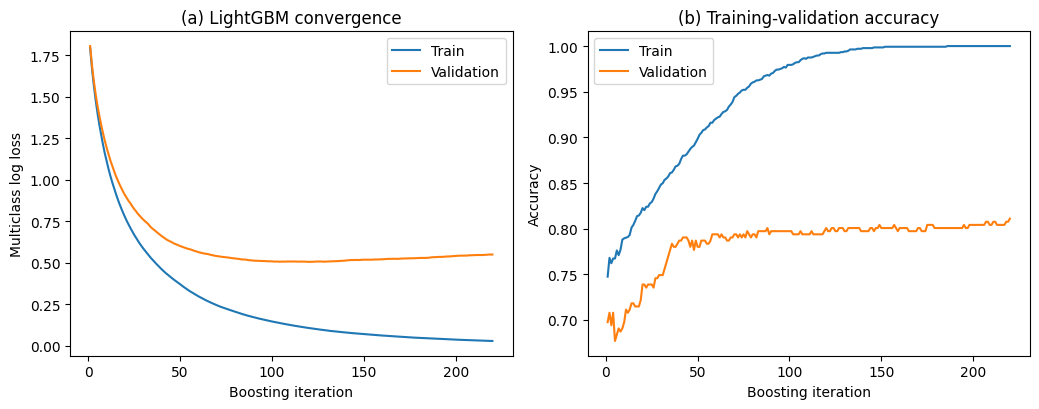

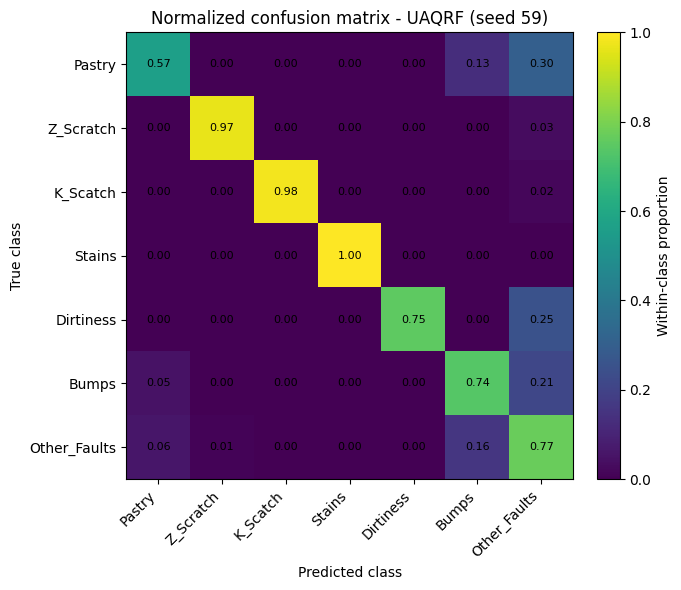

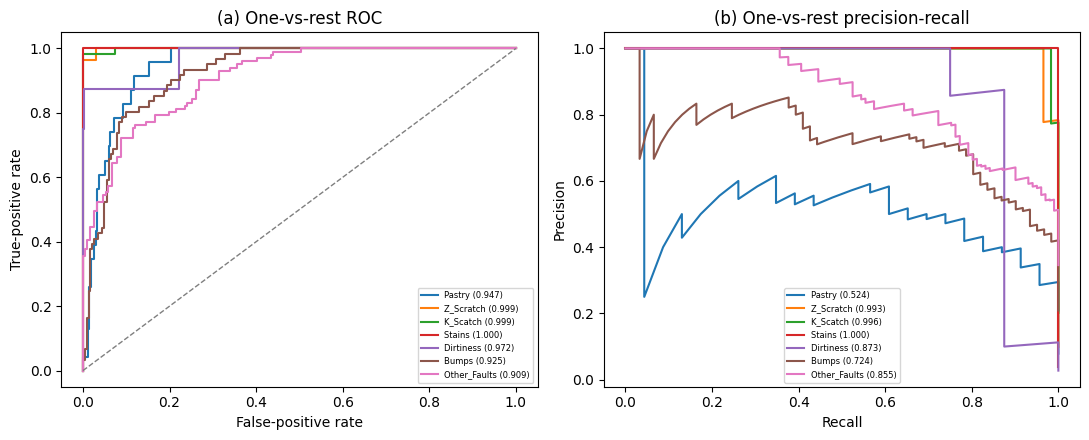

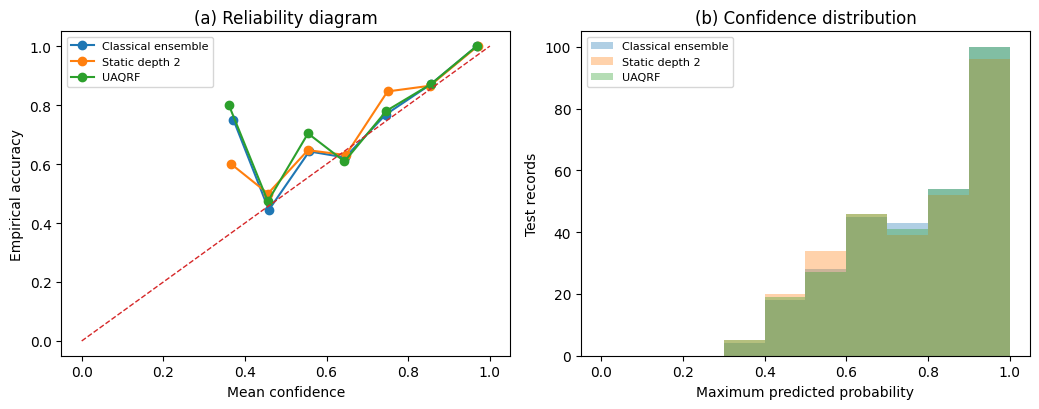

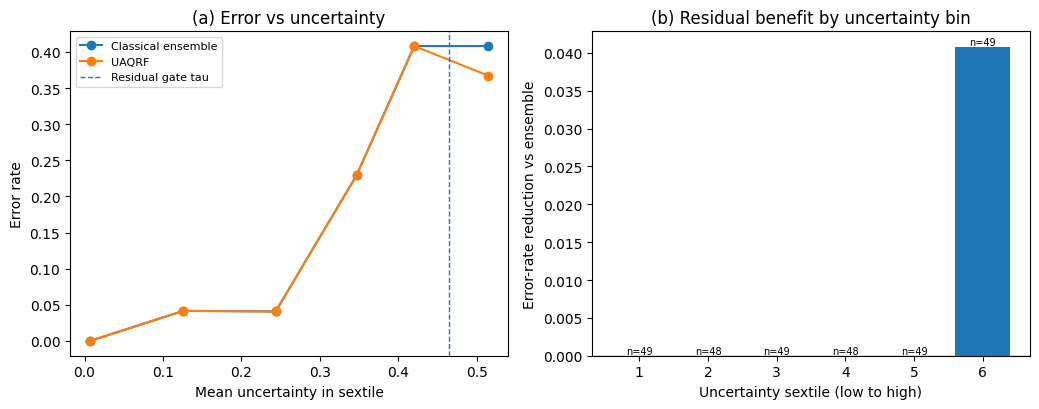

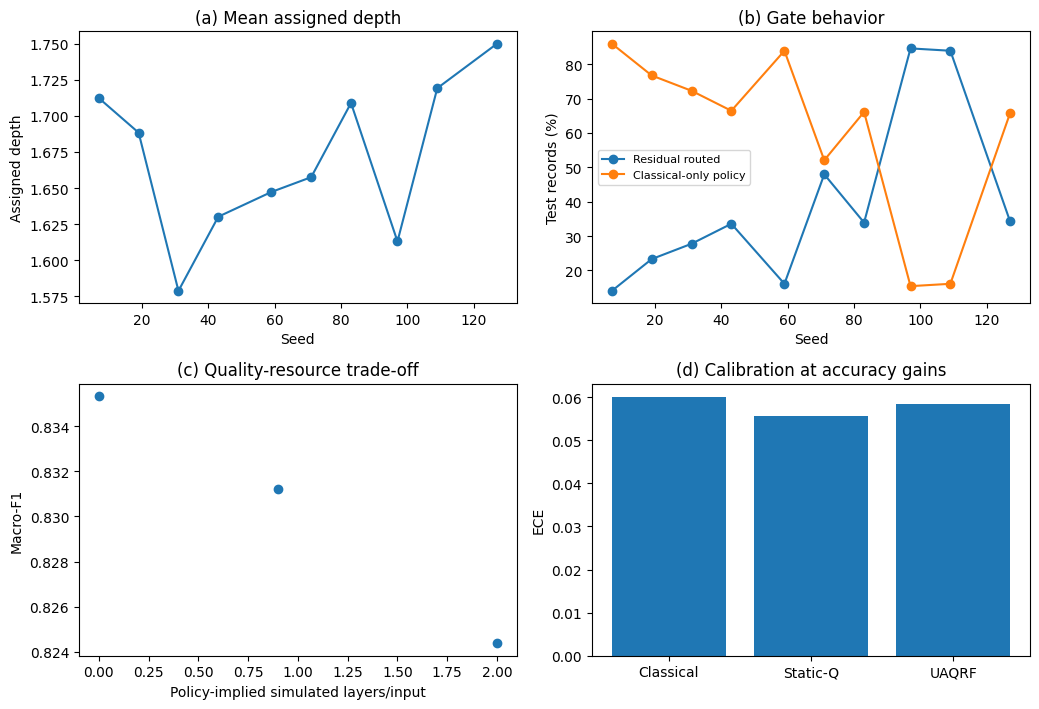

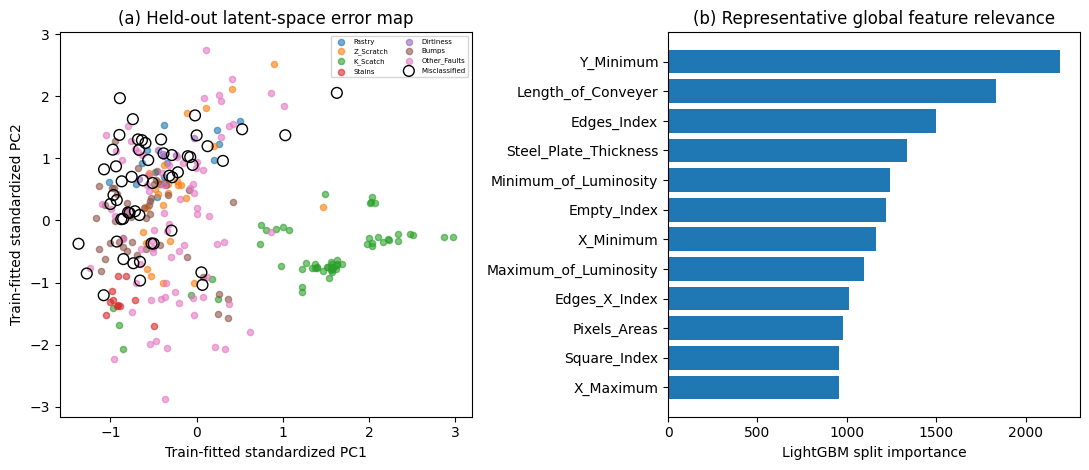

In [14]:
# Reproduce representative seed-59 state and manuscript Figures 9-15
from lightgbm import record_evaluation
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

seed = 59
idx = np.arange(len(y))
tr, tmp = train_test_split(idx, test_size=.30, stratify=y, random_state=seed)
va, te = train_test_split(tmp, test_size=.50, stratify=y[tmp], random_state=seed+997)
sc = StandardScaler().fit(X[tr])
Xtr, Xv, Xte = sc.transform(X[tr]), sc.transform(X[va]), sc.transform(X[te])
pca = PCA(n_components=6, random_state=seed).fit(Xtr)
zsc = StandardScaler().fit(pca.transform(Xtr))
Ztr, Zv, Zte = zsc.transform(pca.transform(Xtr)), zsc.transform(pca.transform(Xv)), zsc.transform(pca.transform(Xte))

p1o, p2o, m1, m2 = oof(Xtr, y[tr], seed)
p1v, p2v = m1.predict_proba(Xv), m2.predict_proba(Xv)
p1t, p2t = m1.predict_proba(Xte), m2.predict_proba(Xte)
pv, pt = (p1v+p2v)/2, (p1t+p2t)/2
uo, uv, ut = uncertainty(p1o,p2o), uncertainty(p1v,p2v), uncertainty(p1t,p2t)
t1, t2 = np.quantile(uo,[.50,.80])
dtr=np.where(uo<t1,1,np.where(uo<t2,2,3)); dv=np.where(uv<t1,1,np.where(uv<t2,2,3)); dte=np.where(ut<t1,1,np.where(ut<t2,2,3))
Qtr,Qv,Qte=qmat(Ztr,dtr),qmat(Zv,dv),qmat(Zte,dte)
meta=LogisticRegression(max_iter=2500,class_weight='balanced',C=.6).fit(np.c_[p1o,p2o,Ztr,Qtr,uo],y[tr])
pmv=meta.predict_proba(np.c_[p1v,p2v,Zv,Qv,uv]); pmt=meta.predict_proba(np.c_[p1t,p2t,Zte,Qte,ut])
best=(-1,None,None)
for tau in np.quantile(uv,np.linspace(.15,.85,15)):
    for alpha in np.linspace(.1,1.0,10):
        pp=np.where((uv>=tau)[:,None],(1-alpha)*pv+alpha*pmv,pv)
        s=f1_score(y[va],pp.argmax(1),average='macro')
        if s>best[0]: best=(s,float(tau),float(alpha))
_, tau, alpha = best
prop=np.where((ut>=tau)[:,None],(1-alpha)*pt+alpha*pmt,pt)
yt=y[te]

# matched static-depth-2 comparator for calibration/resource plots
Q2tr,Q2v,Q2te=qmat(Ztr,np.full(len(tr),2)),qmat(Zv,np.full(len(va),2)),qmat(Zte,np.full(len(te),2))
meta2=LogisticRegression(max_iter=2500,class_weight='balanced',C=.6).fit(np.c_[p1o,p2o,Ztr,Q2tr,uo],y[tr])
pmv2=meta2.predict_proba(np.c_[p1v,p2v,Zv,Q2v,uv]); pmt2=meta2.predict_proba(np.c_[p1t,p2t,Zte,Q2te,ut])
best2=(-1,None,None)
for tau2 in np.quantile(uv,np.linspace(.15,.85,15)):
    for alpha2 in np.linspace(.1,1.0,10):
        pp=np.where((uv>=tau2)[:,None],(1-alpha2)*pv+alpha2*pmv2,pv)
        s=f1_score(y[va],pp.argmax(1),average='macro')
        if s>best2[0]: best2=(s,float(tau2),float(alpha2))
_,tau2,alpha2=best2
static2=np.where((ut>=tau2)[:,None],(1-alpha2)*pt+alpha2*pmt2,pt)
print('seed-59 macro-F1:', f1_score(yt,prop.argmax(1),average='macro'), 'tau:',tau,'alpha:',alpha)

# Fig. 9 - convergence diagnostics (representative LightGBM expert)
E={}
lgb=LGBMClassifier(n_estimators=220,learning_rate=.045,num_leaves=15,class_weight='balanced',random_state=59,verbosity=-1,n_jobs=2)
lgb.fit(Xtr,y[tr],eval_set=[(Xtr,y[tr]),(Xv,y[va])],eval_names=['train','validation'],
        eval_metric=['multi_logloss','multi_error'],callbacks=[record_evaluation(E)])
it=np.arange(1,len(E['train']['multi_logloss'])+1)
fig,axs=plt.subplots(1,2,figsize=(10.5,4.2))
axs[0].plot(it,E['train']['multi_logloss'],label='Train'); axs[0].plot(it,E['validation']['multi_logloss'],label='Validation')
axs[0].set(xlabel='Boosting iteration',ylabel='Multiclass log loss',title='(a) LightGBM convergence'); axs[0].legend()
axs[1].plot(it,1-np.array(E['train']['multi_error']),label='Train'); axs[1].plot(it,1-np.array(E['validation']['multi_error']),label='Validation')
axs[1].set(xlabel='Boosting iteration',ylabel='Accuracy',title='(b) Training-validation accuracy'); axs[1].legend()
fig.tight_layout(); fig.savefig('Figure_9_LightGBM_Training_Validation_Curves.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 10 - row-normalized confusion matrix
cmn=confusion_matrix(yt,prop.argmax(1),normalize='true')
fig,ax=plt.subplots(figsize=(7.4,6)); im=ax.imshow(cmn,vmin=0,vmax=1)
ax.set_xticks(range(7),CLASS_NAMES,rotation=45,ha='right'); ax.set_yticks(range(7),CLASS_NAMES)
ax.set(xlabel='Predicted class',ylabel='True class',title='Normalized confusion matrix - UAQRF (seed 59)')
for i in range(7):
    for j in range(7): ax.text(j,i,f'{cmn[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,fraction=.046,pad=.04,label='Within-class proportion'); fig.tight_layout()
fig.savefig('Figure_10_Normalized_Confusion_Matrix.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 11 - ROC and precision-recall, deliberately paired because imbalance makes both necessary
Yb=label_binarize(yt,classes=np.arange(7)); fig,axs=plt.subplots(1,2,figsize=(11,4.5))
for c,n in enumerate(CLASS_NAMES):
    fpr,tpr,_=roc_curve(Yb[:,c],prop[:,c]); axs[0].plot(fpr,tpr,label=f'{n} ({auc(fpr,tpr):.3f})')
    pr,re,_=precision_recall_curve(Yb[:,c],prop[:,c]); ap=average_precision_score(Yb[:,c],prop[:,c]); axs[1].plot(re,pr,label=f'{n} ({ap:.3f})')
axs[0].plot([0,1],[0,1],linestyle='--',linewidth=1); axs[0].set(xlabel='False-positive rate',ylabel='True-positive rate',title='(a) One-vs-rest ROC'); axs[0].legend(fontsize=6)
axs[1].set(xlabel='Recall',ylabel='Precision',title='(b) One-vs-rest precision-recall'); axs[1].legend(fontsize=6)
fig.tight_layout(); fig.savefig('Figure_11_Discrimination_ROC_PR.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 12 - calibration and confidence distribution
bins=np.linspace(0,1,11); fig,axs=plt.subplots(1,2,figsize=(10.5,4.2))
for name,pp in [('Classical ensemble',pt),('Static depth 2',static2),('UAQRF',prop)]:
    conf=pp.max(1); ok=(pp.argmax(1)==yt).astype(float); xs=[]; ys=[]
    for lo,hi in zip(bins[:-1],bins[1:]):
        m=(conf>=lo)&(conf<(hi+1e-12))
        if m.any(): xs.append(conf[m].mean()); ys.append(ok[m].mean())
    axs[0].plot(xs,ys,marker='o',label=name); axs[1].hist(conf,bins=bins,alpha=.35,label=name)
axs[0].plot([0,1],[0,1],linestyle='--',linewidth=1); axs[0].set(xlabel='Mean confidence',ylabel='Empirical accuracy',title='(a) Reliability diagram'); axs[0].legend(fontsize=8)
axs[1].set(xlabel='Maximum predicted probability',ylabel='Test records',title='(b) Confidence distribution'); axs[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig('Figure_12_Calibration_Reliability.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 13 - uncertainty-conditioned error and residual benefit
q=np.quantile(ut,np.linspace(0,1,7)); centers=[]; eb=[]; ep=[]; gain=[]; ns=[]
for i in range(6):
    m=(ut>=q[i])&(ut<(q[i+1]+(1e-12 if i==5 else 0)))
    centers.append(ut[m].mean()); ns.append(m.sum())
    b=(pt[m].argmax(1)!=yt[m]).mean(); a=(prop[m].argmax(1)!=yt[m]).mean(); eb.append(b); ep.append(a); gain.append(b-a)
fig,axs=plt.subplots(1,2,figsize=(10.5,4.2))
axs[0].plot(centers,eb,marker='o',label='Classical ensemble'); axs[0].plot(centers,ep,marker='o',label='UAQRF'); axs[0].axvline(tau,linestyle='--',linewidth=1,label='Residual gate tau')
axs[0].set(xlabel='Mean uncertainty in sextile',ylabel='Error rate',title='(a) Error vs uncertainty'); axs[0].legend(fontsize=8)
axs[1].bar(range(1,7),gain); axs[1].axhline(0,linewidth=1); axs[1].set(xlabel='Uncertainty sextile (low to high)',ylabel='Error-rate reduction vs ensemble',title='(b) Residual benefit by uncertainty bin')
for i,n in enumerate(ns): axs[1].text(i+1,gain[i],f'n={n}',ha='center',va='bottom' if gain[i]>=0 else 'top',fontsize=7)
fig.tight_layout(); fig.savefig('Figure_13_Uncertainty_Conditioned_Benefit.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 14 - ten-seed routing/resource robustness. Lazy quantity is clearly labeled policy-implied.
ad=adaptation.copy(); order=['Classical ensemble','Static-depth Q fusion','Proposed UAQRF']; agg=results.groupby('model').mean(numeric_only=True)
fig,axs=plt.subplots(2,2,figsize=(10.5,7.2))
axs[0,0].plot(ad.seed,ad.avg_depth,marker='o'); axs[0,0].set(xlabel='Seed',ylabel='Assigned depth',title='(a) Mean assigned depth')
axs[0,1].plot(ad.seed,100*ad.routed,marker='o',label='Residual routed'); axs[0,1].plot(ad.seed,100*ad.bypass,marker='o',label='Classical-only policy'); axs[0,1].set(xlabel='Seed',ylabel='Test records (%)',title='(b) Gate behavior'); axs[0,1].legend(fontsize=8)
x=[0,2,ad.effective_layers.mean()]; y=[agg.loc[m,'macro_f1'] for m in order]
axs[1,0].scatter(x,y); axs[1,0].set(xlabel='Policy-implied simulated layers/input',ylabel='Macro-F1',title='(c) Quality-resource trade-off')
ecevals=[agg.loc[m,'ece'] for m in order]; axs[1,1].bar(['Classical','Static-Q','UAQRF'],ecevals); axs[1,1].set(ylabel='ECE',title='(d) Calibration at accuracy gains')
fig.tight_layout(); fig.savefig('Figure_14_Routing_Resource_Robustness.png',dpi=320,bbox_inches='tight'); plt.show()

# Fig. 15 - latent overlap + representative global feature relevance
pred=prop.argmax(1); correct=pred==yt; fig,axs=plt.subplots(1,2,figsize=(11,4.8))
for c,n in enumerate(CLASS_NAMES):
    m=(yt==c)&correct; axs[0].scatter(Zte[m,0],Zte[m,1],s=20,alpha=.6,label=n)
err=~correct; axs[0].scatter(Zte[err,0],Zte[err,1],s=60,facecolors='none',edgecolors='k',linewidths=1,label='Misclassified')
axs[0].set(xlabel='Train-fitted standardized PC1',ylabel='Train-fitted standardized PC2',title='(a) Held-out latent-space error map'); axs[0].legend(fontsize=5,ncol=2)
imp=pd.Series(m1.feature_importances_,index=Xdf.columns).sort_values(ascending=False).head(12).sort_values()
axs[1].barh(imp.index,imp.values); axs[1].set(xlabel='LightGBM split importance',title='(b) Representative global feature relevance')
fig.tight_layout(); fig.savefig('Figure_15_Latent_Space_Feature_Relevance.png',dpi=320,bbox_inches='tight'); plt.show()

# Machine-readable representative diagnostics
np.savez_compressed('seed59_diagnostics.npz',test_idx=te,ytest=yt,proposed=prop,base=pt,static2=static2,uncertainty=ut,depth=dte,Zte=Zte,tau=tau,alpha=alpha)
